In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Iniciando el proceso de Ingeniería de Características...
DataFrame con características numéricas creado:
   eventID  n_hits  radius_mean  radius_std      beta
0        0      30   143.138471  115.512764  0.977399
1        1      60    88.239521   78.425421  0.977399
2        2      28   132.783066   96.344357  0.977399
3        3      31   123.311964   86.044087  0.977399
4        4      49    88.977087   47.191404  0.977399

Total de eventos procesados: 249904

Datos listos para entrenar. Forma de X_train: (199923, 3)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/200
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0126 - r2_score: -219.9339 - val_loss: 4.8712e-05 - val_r2_score: 0.1503
Epoch 2/200
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 8.6478e-05 - r2_score: -0.5176 - val_loss: 4.0481e-05 - val_r2_score: 0.2928
Epoch 3/200
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 6.8136e-05 - r2_score: -0.1989 - val_loss: 3.8111e-05 - val_r2_score: 0.3336
Epoch 4/200
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 5.5466e-05 - r2_score: 0.0265 - val_loss: 3.1900e-05 - val_r2_score: 0.4421
Epoch 5/200
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 4.0136e-05 - r2_score: 0.2957 - val_loss: 1.6613e-05 - val_r2_score: 0.7094
Epoch 6/200
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 2.9657e-05 - r2_score: 0.4784 - val_loss: 1.5405e-05 - val_r2_score: 0.7306
Epoch 7/200
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 2.1546e-05 - r2_score: 0.6216 - val_loss: 1.3236e-05 - val_r2_score: 0.7686
Epoch 8/200
1562/1562 ━━━

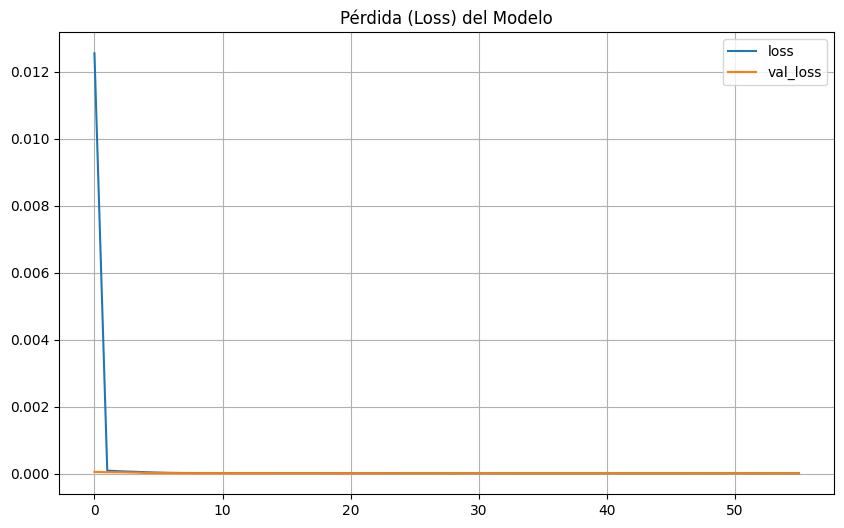

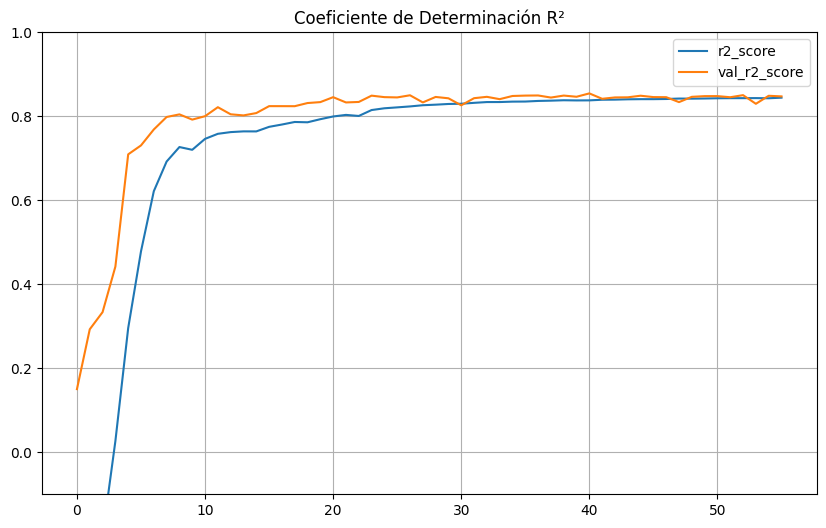

In [ ]:
import os, shutil, math
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     Flatten, Dense, BatchNormalization,
                                     Activation, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from scipy.stats import gaussian_kde
from scipy.stats import mode

#Función para calcular beta teórica
M = 938.272           # MeV/c²

def beta(E, m=M):
    γ = 1.0 + E/m
    return math.sqrt(1.0 - 1.0/γ**2)

#CUANRIZAR
#def cuantizar_hits(x, y, paso=8.5, x0=0.0, y0=0.0, modo="centro"):
#
#    i = np.floor((x - x0) / paso).astype(int)
#    j = np.floor((y - y0) / paso).astype(int)
#
#    if modo == "centro":
#        xq = x0 + (i + 0.5) * paso
#        yq = y0 + (j + 0.5) * paso
#    elif modo == "floor":
#        xq = x0 + i * paso
#        yq = y0 + j * paso
#    else:
#        raise ValueError("modo debe ser 'centro' o 'floor'")

#    return xq, yq

#RUTA_CSV     = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_3_5GeV_10GeV_full.csv"
RUTA_CSV1 = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_3_5GeV_50000ev.csv"
RUTA_CSV2 = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_4_1GeV_50000ev.csv"
RUTA_CSV3 = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_5_0GeV_50000ev.csv"
RUTA_CSV4 = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_7_0GeV_50000ev.csv"
RUTA_CSV5 = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_20_0GeV_50000ev.csv"

# Cargar primeros hits de cada archivo
df1 = pd.read_csv(RUTA_CSV1)
df2 = pd.read_csv(RUTA_CSV2)
df3 = pd.read_csv(RUTA_CSV3)
df4 = pd.read_csv(RUTA_CSV4)
df5 = pd.read_csv(RUTA_CSV5)

df2['eventID'] = df2['eventID'] + 50000
df3['eventID'] = df3['eventID'] + 100000
df4['eventID'] = df4['eventID'] + 150000
df5['eventID'] = df5['eventID'] + 200000

# Une los DataFrames
df_uno = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)
#df_uno = pd.read_csv(RUTA_CSV)

# Convierte a numérico las columnas relevantes (por si hay strings u otros problemas)
cols_to_center = ["x(mm)", "y(mm)"]

# Asegura que son numéricas
df_uno[cols_to_center] = df_uno[cols_to_center].apply(pd.to_numeric, errors='coerce')

# Calcula el centroide (media) por evento
#df_uno[["x0(mm)", "y0(mm)"]] = df_uno.groupby("eventID")[cols_to_center].transform("mean")

# Centrar por evento
df_centered = df_uno.copy()
df_centered[cols_to_center] = df_centered[cols_to_center] - df_centered[["x0(mm)", "y0(mm)"]].to_numpy()

#df_centered["x(mm)"], df_centered["y(mm)"] = cuantizar_hits(df_centered["x(mm)"].values, df_centered["y(mm)"].values, paso=8.5, x0=0.0, y0=0.0, modo="centro")


# Eliminar puntos dentro de un radio mínimo
#radio_minimo = 10  # mm
#distancia = np.sqrt(df_centered["x(mm)"]**2 + df_centered["y(mm)"]**2)
#df_filtrado = df_centered[distancia >= radio_minimo].copy()

#df_filtrado.reset_index(drop=True, inplace=True)

df_filtrado = df_centered.copy()

print("Iniciando el proceso de Ingeniería de Características...")

# Extracción de Características

# Calcula la distancia de cada punto al centro (0,0)
df_filtrado['radius'] = np.sqrt(df_filtrado['x(mm)']**2 + df_filtrado['y(mm)']**2)

# Agrupa por evento y calcula las características agregadas
features_list = []
energy_col = next(c for c in df_filtrado.columns if "energy" in c.lower())

for event_id, grp in df_filtrado.groupby('eventID'):
    # Características extraídas del anillo
    n_hits = len(grp)

    #CAMBIE EL ENTRENAMIENTO A LA MODA
    #radii_rounded = np.round(grp['radius'].values, 1)
    #radius_mean = mode(radii_rounded, keepdims=True)[0][0]

    radius_mean = grp['radius'].mean()
    radius_std = grp['radius'].std()

    # Obtener la energía y calcular beta
    energy = grp[energy_col].iloc[0]
    beta_val = beta(energy)

    features_list.append({
        'eventID': event_id,
        'n_hits': n_hits,
        'radius_mean': radius_mean,
        'radius_std': radius_std,
        'beta': beta_val
    })

# Crea un nuevo DataFrame con una fila por evento
df_features = pd.DataFrame(features_list).fillna(0) # .fillna(0) por si std es NaN (eventos con 1 solo hit)

print("DataFrame con características numéricas creado:")
print(df_features.head())
print(f"\nTotal de eventos procesados: {len(df_features)}")

# Preparación de los Datos

# Separa las características (X) y la etiqueta (y)
features = ['n_hits', 'radius_mean', 'radius_std']
target = 'beta'

X = df_features[features]
y = df_features[target]

# Divide en conjuntos de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Escala las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

#scaler_y = StandardScaler()
#y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
#y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))

print(f"\nDatos listos para entrenar. Forma de X_train: {X_train_scaled.shape}")

#Creación del Modelo (Red Neuronal Densa / MLP)

# Métrica R² personalizada
def r2_score(y_true, y_pred):
    ss_res = tf.keras.backend.sum(tf.keras.backend.square(y_true - y_pred))
    ss_tot = tf.keras.backend.sum(tf.keras.backend.square(y_true - tf.keras.backend.mean(y_true)))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())

# Definición del modelo
inp = tf.keras.Input(shape=(len(features),)) # La entrada es el vector de 3 características
#x = tf.keras.layers.Dense(128, activation='relu')(inp)
x = tf.keras.layers.Dense(64, activation='relu')(inp)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.05)(x)
#x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.05)(x)

# Capa de salida acotada
x = tf.keras.layers.Dense(1, activation='sigmoid')(x)
out = tf.keras.layers.Lambda(lambda v: v * 1)(x)

model = tf.keras.Model(inp, out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[r2_score]
)

model.summary()

# Entrenamiento y Evaluación

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
]

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

# Graficar resultados
print("\nEntrenamiento finalizado. Mostrando gráficas de rendimiento...")
pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(10, 6))
plt.title('Pérdida (Loss) del Modelo')
plt.grid(True)
plt.show()

pd.DataFrame(history.history)[['r2_score', 'val_r2_score']].plot(figsize=(10, 6))
plt.title('Coeficiente de Determinación R²')
plt.ylim(-0.1, 1) # Ajusta el eje Y para ver mejor si R² se vuelve positivo
plt.grid(True)

Esta celda contiene la mayor parte del código para entrenar un modelo de red neuronal (un Perceptrón Multicapa o MLP) para predecir la velocidad beta ($\beta$) de una partícula. El proceso se divide en las siguientes fases:

#### 1. **Configuración Inicial**
- **Importaciones**: Se importan todas las librerías necesarias:
    - `numpy` y `pandas` para manipulación de datos.
    - `matplotlib` para visualización.
    - `sklearn` para dividir los datos y escalarlos.
    - `tensorflow.keras` para construir y entrenar la red neuronal.
- **Funciones Auxiliares**:
    - `beta(E)`: Calcula la velocidad teórica ($\beta$) de una partícula a partir de su energía cinética `E`. Este valor se usará como la "verdad" (etiqueta) para entrenar el modelo.
    - `cuantizar_hits(x, y)`: Agrupa las coordenadas `(x, y)` en una grilla discreta, similar a píxeles.

#### 2. **Preprocesamiento de Datos**
- **Carga**: Se lee un archivo CSV (`Prueba.csv`) que contiene los datos de los *hits*.
- **Centrado**: Para cada "evento" (un conjunto de *hits* de una misma partícula), se calcula el centroide (la posición promedio) y se restan esas coordenadas a todos los *hits* del evento. Esto centra cada anillo de Cherenkov en el origen `(0,0)`, eliminando la variación por la posición.
- **Cuantización**: Se aplica la función `cuantizar_hits` para ajustar las posiciones a una grilla.
- **Filtrado Radial**: Se eliminan los *hits* que están muy cerca del centro (dentro de un `radio_minimo` de 20 mm). Esto ayuda a limpiar el ruido que puede haber en el centro del detector.

#### 3. **Ingeniería de Características (Feature Engineering)**
En lugar de usar las imágenes de los *hits*, este modelo usa características numéricas extraídas de ellos:
- Se calcula la distancia (`radius`) de cada *hit* al centro `(0,0)`.
- Para cada evento, se agrupan los *hits* y se calculan tres características:
    1.  **`n_hits`**: El número total de *hits*.
    2.  **`radius_mean`**: El radio promedio de los *hits*.
    3.  **`radius_std`**: La desviación estándar de los radios, que indica qué tan disperso o bien definido está el anillo.
- Estas características, junto con la $\beta$ teórica, se guardan en un nuevo DataFrame `df_features`.

#### 4. **Preparación para el Entrenamiento**
- **División de Datos**: Las características (`n_hits`, `radius_mean`, `radius_std`) se definen como `X` (entrada del modelo), y la `beta` teórica se define como `y` (salida deseada). El conjunto de datos se divide en un 80% para entrenamiento (`X_train`, `y_train`) y un 20% para validación (`X_val`, `y_val`).
- **Escalado**: Se utiliza `StandardScaler` de `sklearn` para estandarizar las características de entrada `X`. Esto asegura que todas las características tengan una media de 0 y una desviación estándar de 1, lo cual es crucial para que las redes neuronales aprendan eficientemente.

#### 5. **Construcción del Modelo (MLP)**
- **Métrica**: Se define una función `r2_score` para calcular el coeficiente de determinación (R²), que mide qué tan bien las predicciones del modelo se ajustan a los datos reales.
- **Arquitectura**: Se construye una red neuronal secuencial simple:
    - **Capa de Entrada**: Acepta un vector con las 3 características de entrada.
    - **Capas Ocultas**: Dos capas densas (`Dense`) con activación `relu`, intercaladas con `BatchNormalization` (para estabilizar el entrenamiento) y `Dropout` (para prevenir el sobreajuste).
    - **Capa de Salida**: Una capa `Dense` con una sola neurona y activación `sigmoid`, que produce una salida entre 0 y 1.
- **Compilación**: El modelo se compila con el optimizador `Adam`, la función de pérdida de error cuadrático medio (`mse`), y se monitorea con la métrica `r2_score`.

#### 6. **Entrenamiento y Evaluación**
- **Entrenamiento**: El modelo se entrena usando el método `model.fit` con los datos de entrenamiento escalados.
    - Se usa un *callback* de `EarlyStopping` que detiene el entrenamiento si la pérdida en los datos de validación no mejora durante 15 épocas, restaurando los mejores pesos encontrados para evitar el sobreajuste.
- **Visualización**: Al finalizar el entrenamiento, se generan dos gráficos:
    1.  **Pérdida (Loss)**: Muestra cómo el error del modelo (`loss` y `val_loss`) disminuye a lo largo de las épocas.
    2.  **Coeficiente de Determinación (R²)**: Muestra cómo la métrica R² (`r2_score` y `val_r2_score`) mejora con el entrenamiento, acercándose idealmente a 1.

In [ ]:
# =====================================================================
# APLICACIÓN DEL PROTOCOLO DE DIAGNÓSTICO (PASOS 3, 4 Y 5)
# =====================================================================
from sklearn.metrics import r2_score as sklearn_r2

print("\n" + "="*50)
print("INICIANDO PROTOCOLO DE DIAGNÓSTICO FÍSICO")
print("="*50)

# ---------------------------------------------------------
# PASO 3: Escaneo de Gradientes (CORREGIDO)
# ---------------------------------------------------------
print("\n[Paso 3] Escaneo de Gradientes por Capa...")
# Tomamos un pequeño lote del conjunto de validación
x_batch = tf.convert_to_tensor(X_val_scaled[:64], dtype=tf.float32)

# Es importante asegurarse de que y_batch tenga la forma correcta (64, 1) para que coincida con las predicciones
y_batch = tf.convert_to_tensor(y_val[:64].values, dtype=tf.float32)
y_batch = tf.reshape(y_batch, (-1, 1))

with tf.GradientTape() as tape:
    preds_batch = model(x_batch, training=True)
    # Calculamos el MSE usando las operaciones matemáticas de TensorFlow directamente (a prueba de fallos de versión)
    loss_val = tf.reduce_mean(tf.square(y_batch - preds_batch))

# Calculamos los gradientes respecto a los pesos entrenables
grads = tape.gradient(loss_val, model.trainable_weights)

for var, grad in zip(model.trainable_weights, grads):
    if grad is not None:
        print(f" - Capa: {var.name} | Norma del gradiente: {tf.norm(grad).numpy():.6f}")
    else:
        print(f" - Capa: {var.name} | Gradiente: None")

# ---------------------------------------------------------
# PASO 4: Pruebas de perturbación de pesos
# ---------------------------------------------------------
print("\n[Paso 4] Pruebas de robustez (Perturbación de pesos)...")
# Calculamos el R2 original con sklearn para tener una base sólida
preds_orig = model.predict(X_val_scaled, verbose=0)
r2_orig = sklearn_r2(y_val, preds_orig)
print(f" - R2 Original en validación: {r2_orig:.4f}")

# Extraemos la primera capa oculta (Dense de 64 neuronas, que es la capa 1)
capa_1 = model.layers[1]
pesos_orig = capa_1.get_weights()

# Aplicamos un ruido gaussiano controlado (escala de 0.05) a los pesos
ruido = [np.random.normal(loc=0.0, scale=0.05, size=w.shape) for w in pesos_orig]
pesos_perturbados = [w + r for w, r in zip(pesos_orig, ruido)]
capa_1.set_weights(pesos_perturbados)

# Evaluamos el modelo perturbado
preds_pert = model.predict(X_val_scaled, verbose=0)
r2_pert = sklearn_r2(y_val, preds_pert)
print(f" - R2 con pesos perturbados (Capa 1): {r2_pert:.4f}")

# Restauramos los pesos originales inmediatamente
capa_1.set_weights(pesos_orig)
print(" - Pesos originales restaurados con éxito.")

# ---------------------------------------------------------
# PASO 5: Validación mediante interpretabilidad
# ---------------------------------------------------------
print("\n[Paso 5] Importancia de Características (Permutación)...")
importancias = {}

for i, col in enumerate(features):
    # Copiamos el set de validación escalado
    X_val_permuted = X_val_scaled.copy()
    # Rompemos la relación de la característica 'i' mezclándola aleatoriamente
    np.random.shuffle(X_val_permuted[:, i])

    # Predecimos con la variable dañada
    preds_permuted = model.predict(X_val_permuted, verbose=0)
    permuted_r2 = sklearn_r2(y_val, preds_permuted)

    # La importancia es cuánto cae el rendimiento al dañar la variable
    caida_r2 = r2_orig - permuted_r2
    importancias[col] = caida_r2
    print(f" - Caída en R2 al permutar '{col}': {caida_r2:.4f}")

print("\n" + "-"*50)
print("DIAGNÓSTICO FINAL:")
for col, imp in importancias.items():
    if imp <= 0.01:
        print(f" [ALERTA] La variable '{col}' no aporta valor predictivo significativo. Podría ser ruido.")
    else:
        print(f" [OK] La variable '{col}' es relevante. El modelo se apoya correctamente en ella.")
print("="*50 + "\n")


INICIANDO PROTOCOLO DE DIAGNÓSTICO FÍSICO

[Paso 3] Escaneo de Gradientes por Capa...
 - Capa: kernel | Norma del gradiente: 0.000033
 - Capa: bias | Norma del gradiente: 0.000021
 - Capa: gamma | Norma del gradiente: 0.000012
 - Capa: beta | Norma del gradiente: 0.000015
 - Capa: kernel | Norma del gradiente: 0.000018
 - Capa: bias | Norma del gradiente: 0.000005
 - Capa: gamma | Norma del gradiente: 0.000013
 - Capa: beta | Norma del gradiente: 0.000023
 - Capa: kernel | Norma del gradiente: 0.000073
 - Capa: bias | Norma del gradiente: 0.000027

[Paso 4] Pruebas de robustez (Perturbación de pesos)...
 - R2 Original en validación: 0.8562
 - R2 con pesos perturbados (Capa 1): 0.7992
 - Pesos originales restaurados con éxito.

[Paso 5] Importancia de Características (Permutación)...
 - Caída en R2 al permutar 'n_hits': 0.3712
 - Caída en R2 al permutar 'radius_mean': 1.2579
 - Caída en R2 al permutar 'radius_std': 0.4450

--------------------------------------------------
DIAGNÓSTICO 

In [ ]:
import pickle
model.save("betanet_v5.h5")
with open('data_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

Esta celda guarda los resultados del entrenamiento para poder usarlos en el futuro sin necesidad de volver a entrenar.

1.  **`model.save("betanet_v5.h5")`**: Guarda la arquitectura completa del modelo, sus pesos aprendidos y la configuración del optimizador en un único archivo en formato HDF5 (`.h5`). Este archivo puede ser cargado más tarde para hacer predicciones.

2.  **`pickle.dump(scaler, f)`**: Guarda el objeto `scaler` (el `StandardScaler` que fue ajustado con los datos de entrenamiento) en un archivo llamado `data_scaler.pkl`. Esto es fundamental, ya que para hacer predicciones correctas sobre datos nuevos, estos deben ser escalados *exactamente* de la misma manera que los datos de entrenamiento.

## Predicción 5 eventos nuevos

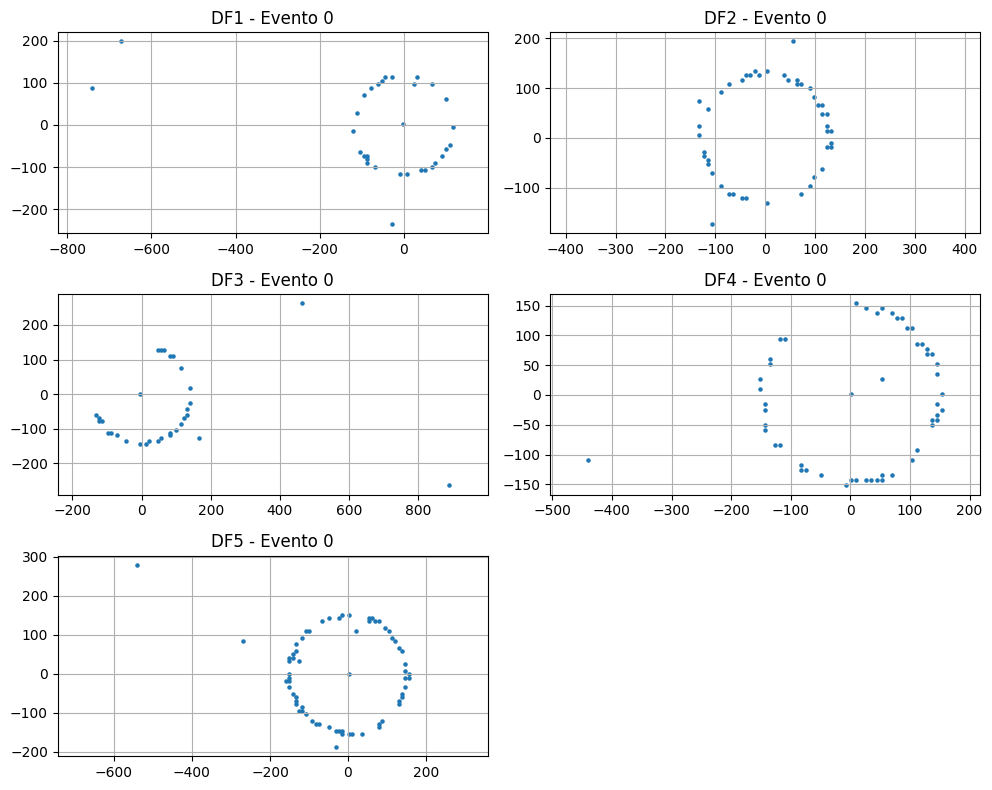

In [ ]:
# Rutas
RUTA_CSV1 = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_3_8GeV_50000ev.csv"
RUTA_CSV2 = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_4_5GeV_50000ev.csv"
RUTA_CSV3 = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_6_0GeV_50000ev.csv"
RUTA_CSV4 = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_8_5GeV_50000ev.csv"
RUTA_CSV5 = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_10_0GeV_50000ev.csv"

# Cargar primeros 500 hits de cada archivo
df1 = pd.read_csv(RUTA_CSV1)
df2 = pd.read_csv(RUTA_CSV2)
df3 = pd.read_csv(RUTA_CSV3)
df4 = pd.read_csv(RUTA_CSV4)
df5 = pd.read_csv(RUTA_CSV5)

dataframes = [df1, df2, df3, df4, df5]

#CUANTIZAR
#for df in dataframes:
#    df["x(mm)"], df["y(mm)"] = cuantizar_hits(
#        df["x(mm)"].to_numpy(),
#        df["y(mm)"].to_numpy(),
#        paso=8.5, x0=0.0, y0=0.0, modo="centro"
#    )

cols_to_center = ["x(mm)", "y(mm)"]

# Asegurar que las columnas son numéricas y centrar por evento
df_centered_list = []
for df in dataframes:
    # Asegurar numérico
    for col in cols_to_center:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df_centered = df.copy()

    # Guardar los centroides (medias por evento) -> devuelve dos columnas
    #df_centered[["x0(mm)", "y0(mm)"]] = df_centered.groupby("eventID")[cols_to_center].transform("mean")

    # Centrar usando esas medias
    df_centered[cols_to_center] = df_centered[cols_to_center] - df_centered[["x0(mm)", "y0(mm)"]].to_numpy() #Centra los datos restando a cada punto el punto central real

    df_centered_list.append(df_centered)

# Graficar un evento por DataFrame
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))
axes = axes.flatten()
titles = ['DF1', 'DF2', 'DF3', 'DF4', 'DF5']

for i, df_centered in enumerate(df_centered_list):
    ax = axes[i]
    # Elegir el primer evento del DataFrame
    first_event = df_centered['eventID'].unique()[0]
    df_event = df_centered[df_centered['eventID'] == first_event]
    ax.scatter(df_event["x(mm)"], df_event["y(mm)"], s=5)
    ax.set_title(f"{titles[i]} - Evento {first_event}")
    ax.axis('equal')
    ax.grid(True)

# Si hay más subplots que DataFrames, ocultar el sobrante
for j in range(len(df_centered_list), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Esta celda se encarga de cargar y preprocesar cinco conjuntos de datos diferentes, cada uno correspondiente a una energía de partícula distinta (3.5, 4, 5, 7 y 10 GeV), para luego visualizar un ejemplo de cada uno.

#### 1. **Carga de Datos**
- Se definen las rutas a cinco archivos CSV diferentes, cada uno etiquetado con la energía de la partícula.
- Se lee cada archivo usando `pandas` y se toman las primeras 50,000 filas (`.head(50000)`) para trabajar con un subconjunto manejable.
- Los DataFrames resultantes se almacenan en una lista llamada `dataframes`.

#### 2. **Visualización de Ejemplos**
- Se crea una figura con una cuadrícula de 3x2 subplots.
- Se itera sobre la lista `df_centered_list`. Para cada DataFrame:
    - Se selecciona el **primer evento** único que aparece en él.
    - Se crea un gráfico de dispersión (`scatter plot`) mostrando las coordenadas `(x, y)` de los *hits* de ese evento.
    - Se ajusta el título del gráfico y se asegura que los ejes tengan la misma escala (`axis('equal')`) para una visualización correcta del anillo.
- El último subplot, que queda vacío, se oculta. Finalmente, `plt.show()` muestra los cinco anillos de Cherenkov de ejemplo.

## Gráfica de un ejemplo por dataset de los datos filtrados


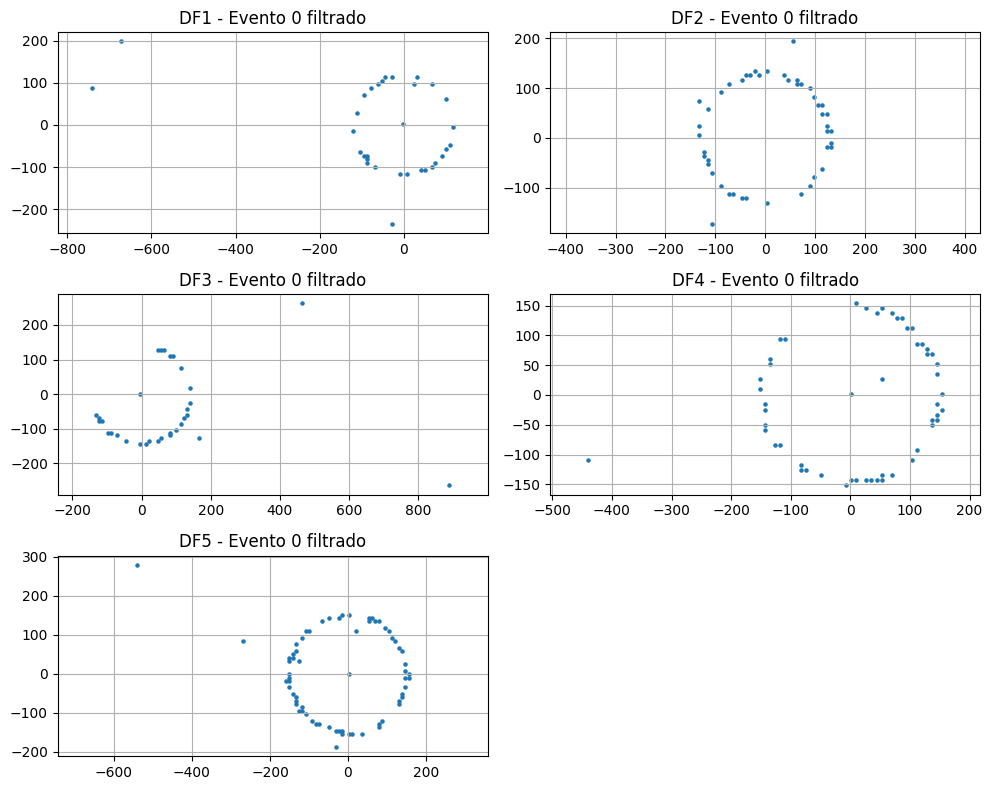

In [ ]:
df_filtrados = df_centered_list

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))
axes = axes.flatten()
titles = ['DF1', 'DF2', 'DF3', 'DF4', 'DF5']

for i, df_filtrado in enumerate(df_filtrados):
    ax = axes[i]
    first_event = df_filtrado['eventID'].unique()[0]
    df_event = df_filtrado[df_filtrado['eventID'] == first_event]
    ax.scatter(df_event["x(mm)"], df_event["y(mm)"], s=5)
    ax.set_title(f"{titles[i]} - Evento {first_event} filtrado")
    ax.axis('equal')
    ax.grid(True)

for j in range(len(df_filtrados), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#df_filtrados = df_centered_list

Esta celda visualiza los datos **después** de haber aplicado el filtro radial de la celda anterior.

- Al igual que antes, crea una cuadrícula de subplots y muestra el primer evento de cada uno de los cinco DataFrames.
- La diferencia es que ahora utiliza la lista `df_filtrados`, que contiene los datos sin los *hits* centrales.
- Al final, la línea `df_filtrados = df_centered_list` reasigna la variable. Esto significa que las celdas posteriores volverán a trabajar con los datos centrados pero **no filtrados** (es decir, con los hits centrales incluidos).

❌ Error: Asegúrate de que los archivos 'betanet.h5' y 'data_scaler.pkl' están en la misma carpeta.

===== Procesando y prediciendo para DataFrame #1 =====
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Predicciones guardadas (Std: 0.002643) para el DataFrame #1.

===== Procesando y prediciendo para DataFrame #2 =====
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Predicciones guardadas (Std: 0.002763) para el DataFrame #2.

===== Procesando y prediciendo para DataFrame #3 =====
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Predicciones guardadas (Std: 0.002804) para el DataFrame #3.

===== Procesando y prediciendo para DataFrame #4 =====
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
✅ Predicciones guardadas (Std: 0.002797) para el DataFrame #4.

===== Procesando y prediciendo para DataFrame #5 =====
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Predicciones guardadas (Std: 0.002744) para el DataFrame #5.


🎉 Todas las predicciones y desviaciones estándar han sido generadas y guardadas.


📊 ====

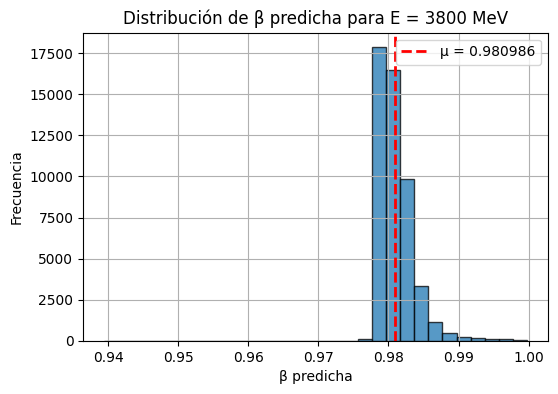

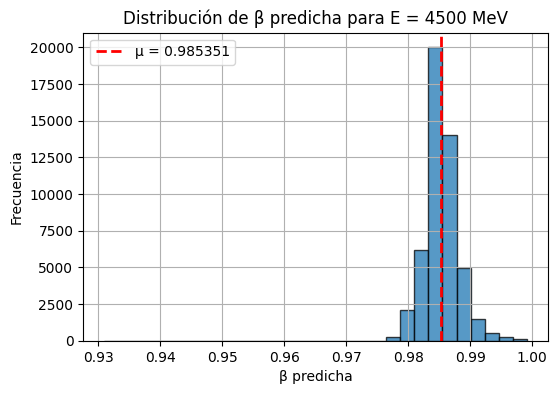

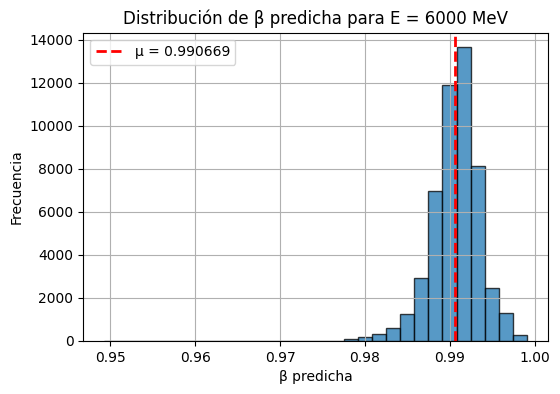

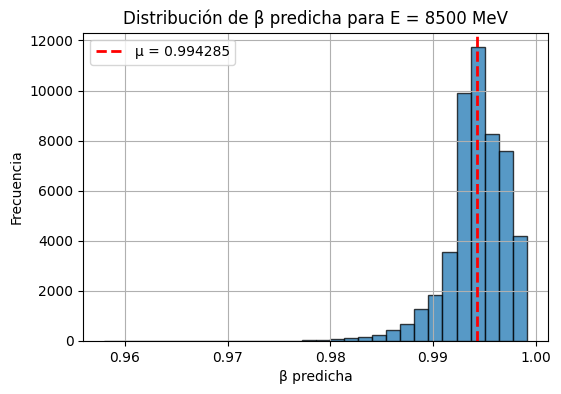

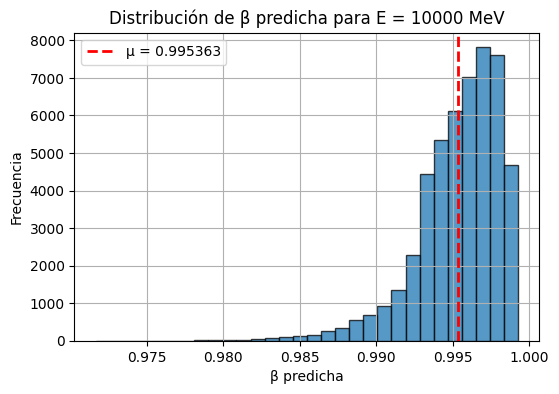

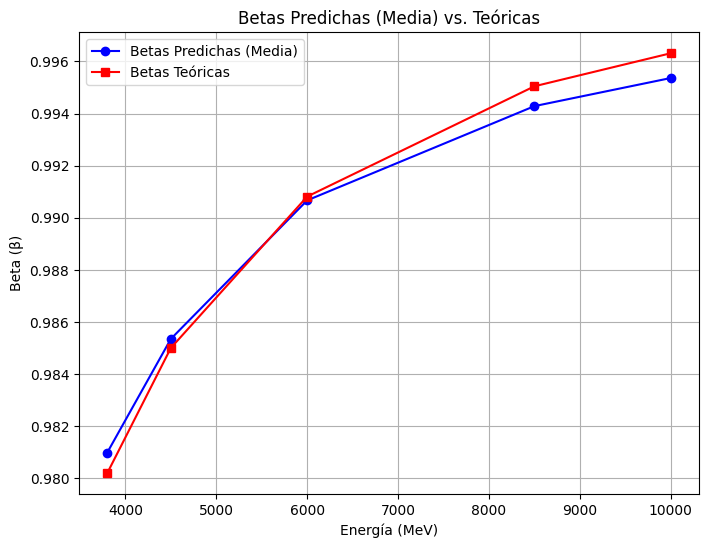

Pendiente de las betas predichas (m): 0.8933397869644064
Pendiente de las betas teóricas (m): 0.9999999999999976
Diferencia de pendientes: 0.10666021303559114


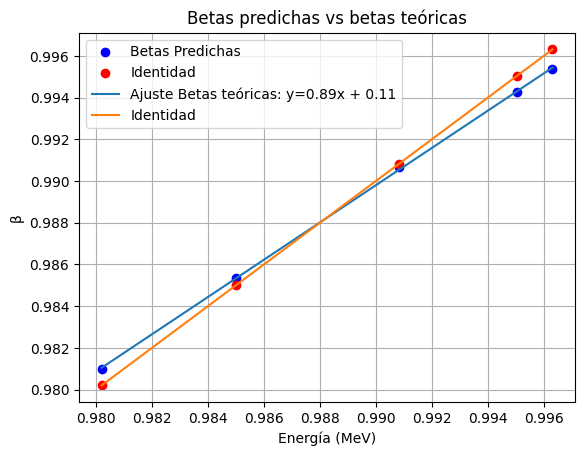

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
import math

# Carga el Modelo y el Escalador
try:
    model = tf.keras.models.load_model(
        "betanet.h5",
        custom_objects={'r2_score': r2_score},
        safe_mode=False
    )

    with open('data_scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)

    print("✅ Modelo y escalador cargados correctamente.")

except FileNotFoundError:
    print("❌ Error: Asegúrate de que los archivos 'betanet.h5' y 'data_scaler.pkl' están en la misma carpeta.")
    exit()

# Listas para guardar los arrays de predicciones y las desviaciones estándar
all_predictions = []
all_std_devs = []  # <-- 1. Lista creada para almacenar la desviación estándar

# Bucle para procesar cada DataFrame y guardar sus predicciones
for i, df_individual_centered in enumerate(df_centered_list):
    print(f"\n===== Procesando y prediciendo para DataFrame #{i+1} =====")

    # Extrae Características
    df_individual_centered['radius'] = np.sqrt(df_individual_centered['x(mm)']**2 + df_individual_centered['y(mm)']**2)
    features_list = []
    for event_id, grp in df_individual_centered.groupby('eventID'):
        features_list.append({
            'eventID': event_id,
            'n_hits': len(grp),
            'radius_mean': grp['radius'].mean(),
            'radius_std': grp['radius'].std()
        })
    df_features = pd.DataFrame(features_list).fillna(0)

    if df_features.empty:
        print("No se encontraron eventos. Saltando al siguiente DataFrame.")
        all_predictions.append(np.array([]))
        all_std_devs.append(np.nan)  # <-- 2. Guarda NaN si no hay datos
        continue

    # Escalar Características
    features_cols = ['n_hits', 'radius_mean', 'radius_std']
    X_new = df_features[features_cols]
    X_new_scaled = scaler.transform(X_new)

    # Realizar Predicciones
    predicted_betas = model.predict(X_new_scaled).flatten()

    # Guardar predicciones y desviación estándar
    all_predictions.append(predicted_betas)

    std_val = np.std(predicted_betas)  # <-- 3. Cálculo de la desviación estándar
    all_std_devs.append(std_val)       # <-- 4. Almacenamiento en la lista

    print(f"✅ Predicciones guardadas (Std: {std_val:.6f}) para el DataFrame #{i+1}.")

print("\n\n🎉 Todas las predicciones y desviaciones estándar han sido generadas y guardadas.")

# ANÁLISIS Y GRAFICACIÓN

# Lista de energías correspondientes a cada uno los DataFrames
E = [3800, 4500, 6000, 8500, 10000]

# Ahora, iteramos sobre la lista de predicciones que acabamos de crear
for k, beta_preds in enumerate(all_predictions):

    # Si no hubo predicciones para este DataFrame, lo saltamos
    if len(beta_preds) == 0:
        continue

    print(f"\n\n📊 ===== Análisis para Energía = {E[k]} MeV =====")

    beta_mean = beta_preds.mean()
    print(f"Media de β_pred sobre {len(beta_preds)} eventos: {beta_mean:.6f}")

    # Grafica la distribución (histograma de barras) y marca la media
    plt.figure(figsize=(6,4))
    n, bins, patches = plt.hist(beta_preds, bins=30, edgecolor='k', alpha=0.75)
    plt.axvline(beta_mean, color='red', linestyle='--', linewidth=2, label=f'μ = {beta_mean:.6f}')
    plt.xlabel('β predicha')
    plt.ylabel('Frecuencia')
    plt.title(f'Distribución de β predicha para E = {E[k]} MeV')
    plt.legend()
    plt.grid(True)



# Lista de energías correspondientes a los DataFrames
E = [3800, 4500, 6000, 8500, 10000]

# Almacenar las medias de las predicciones
mean_predicted_betas = []
betas_teo_list = []

print("\n\n📊 ===== Iniciando Análisis Individual por Energía =====")
# Iteramos sobre la lista de predicciones que creamos antes
for k, beta_preds in enumerate(all_predictions):
    if len(beta_preds) == 0:
        continue

    print(f"\n--- Análisis para Energía = {E[k]} MeV ---")

    beta_mean = beta_preds.mean()
    print(f"Media de β_pred: {beta_mean:.6f}")

    # Calculamos la beta teórica
    beta_teo = beta(E[k])

    # Guarda la media de la predicción y el valor teórico las listas
    mean_predicted_betas.append(beta_mean)
    betas_teo_list.append(beta_teo)

# Graficar las medias vs. las teóricas

plt.figure(figsize=(8, 6))

# Graficar las medias de las predicciones
plt.plot(E, mean_predicted_betas, marker='o', linestyle='-', color='blue', label='Betas Predichas (Media)')

# Graficar los valores teóricos
plt.plot(E, betas_teo_list, marker='s', linestyle='-', color='red', label='Betas Teóricas')

# Añadir título y etiquetas
plt.title('Betas Predichas (Media) vs. Teóricas')
plt.xlabel('Energía (MeV)')
plt.ylabel('Beta (β)')
plt.legend()
plt.grid(True)
plt.show()


betas_teo = np.array(betas_teo_list, dtype=float)
beta_promedios = np.array(mean_predicted_betas, dtype=float)

m1, b1 = np.polyfit(betas_teo, beta_promedios, 1)
m2, b2 = np.polyfit(betas_teo, betas_teo, 1)
print(f"Pendiente de las betas predichas (m): {m1}")
print(f"Pendiente de las betas teóricas (m): {m2}")
print(f'Diferencia de pendientes: {np.abs(m1-m2)}')

plt.scatter(betas_teo, beta_promedios, marker='o', color='blue', label='Betas Predichas')
plt.scatter(betas_teo, betas_teo, marker='o', color='red', label='Identidad')
plt.plot(betas_teo, m1*betas_teo + b1, label=f'Ajuste Betas teóricas: y={m1:.2f}x + {b1:.2f}')
plt.plot(betas_teo, m2*betas_teo + b2, label='Identidad')
plt.title('Betas predichas vs betas teóricas')
plt.xlabel('Energía (MeV)')
plt.ylabel('β')
plt.legend()
plt.grid(True)
plt.show()

Esta celda es el núcleo del análisis. Utiliza el modelo y el escalador previamente guardados para predecir los valores de $\beta$ para los cinco conjuntos de datos y luego realiza un análisis estadístico y visual de los resultados.

#### 1. **Carga del Modelo y Escalador**
- Se cargan el modelo (`betanet.h5`) y el escalador (`data_scaler.pkl`).
- Se utiliza un bloque `try...except` para manejar errores si los archivos no se encuentran.
- **Importante**: El modelo se carga con `compile=False` y luego se vuelve a compilar para evitar errores de deserialización.

#### 2. **Fase 1: Predicción en Lote**
- Se itera sobre cada uno de los cinco DataFrames (`df_centered_list`).
- Dentro del bucle, para cada DataFrame:
    1.  Se repite la **ingeniería de características** del notebook de entrenamiento (cálculo de `n_hits`, `radius_mean`, `radius_std`).
    2.  Las características resultantes (`X_new`) se **escalan** utilizando el `scaler` cargado.
    3.  El método `model.predict()` se usa para obtener un array de valores de $\beta$ predichos.
    4.  Estos arrays de predicciones se guardan en la lista `all_predictions`.

#### 3. **Fase 2: Análisis y Graficación**
- **Análisis por Energía**: El código itera sobre la lista `all_predictions`. Para cada conjunto de predicciones (correspondiente a una energía):
    - Se calcula la **media** de los valores de $\beta$ predichos.
    - Se genera y muestra un **histograma** para visualizar la distribución de las predicciones para esa energía, marcando la media con una línea roja.
- **Gráfica Comparativa Final**:
    - Se almacenan las medias de las betas predichas y se calculan las betas teóricas correspondientes.
    - Se crea un gráfico de líneas que compara la **media de las betas predichas** (azul) con la **beta teórica** (roja) en función de la energía. Esto evalúa si el modelo sigue la tendencia física esperada.
- **Análisis de Correlación (Ajuste Lineal)**:
    - Se realiza un ajuste lineal (`polyfit`) a los datos de $\beta$ predicha vs. $\beta$ teórica.
    - Se crea un gráfico de dispersión que muestra esta correlación, junto con el ajuste lineal y la línea de identidad (y=x), que representa una predicción perfecta.

## Gráfica de betas predichas vs betas teóricas

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


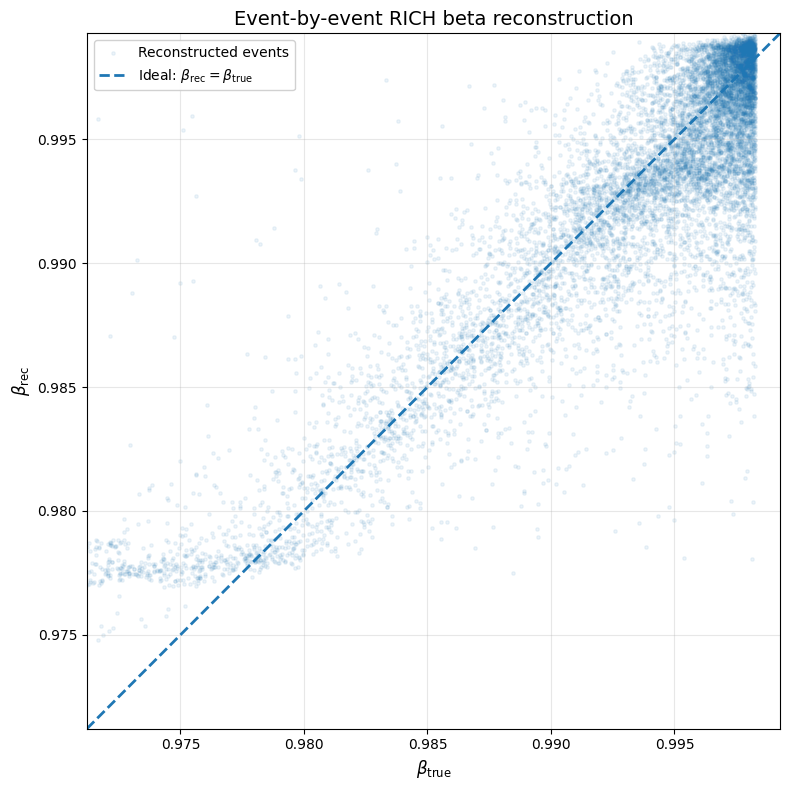

In [ ]:
# 2. Cargar el modelo entrenado y el escalador
custom_objects = {
    'r2_score': lambda y_true, y_pred: 1 - tf.keras.backend.sum(tf.keras.backend.square(y_true - y_pred)) /
                                          (tf.keras.backend.sum(tf.keras.backend.square(y_true - tf.keras.backend.mean(y_true))) + tf.keras.backend.epsilon())
}

# Cargar modelo y scaler previamente guardados
# Cargar modelo permitiendo la deserialización de la capa Lambda
model = tf.keras.models.load_model(
    "betanet_v5.h5",
    custom_objects=custom_objects,
    safe_mode=False,
    compile=False
)
with open('data_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 3. Cargar el dataset de prueba (3 GeV a 15 GeV)
# Actualiza la ruta hacia tu archivo de prueba
RUTA_TEST_CSV = "/content/drive/MyDrive/datos hits/pmt_hits_all_proton_3GeV_15GeV_10000ev.csv"
df_test = pd.read_csv(RUTA_TEST_CSV)

# 4. Preprocesamiento e Ingeniería de Características
cols_to_center = ["x(mm)", "y(mm)"]
df_test[cols_to_center] = df_test[cols_to_center].apply(pd.to_numeric, errors='coerce')

# Centrar por evento si las columnas x0, y0 existen
if "x0(mm)" in df_test.columns and "y0(mm)" in df_test.columns:
    df_test[cols_to_center] = df_test[cols_to_center] - df_test[["x0(mm)", "y0(mm)"]].to_numpy()

df_test['radius'] = np.sqrt(df_test['x(mm)']**2 + df_test['y(mm)']**2)

features_list = []
energy_col = next(c for c in df_test.columns if "energy" in c.lower())

for event_id, grp in df_test.groupby('eventID'):
    features_list.append({
        'eventID': event_id,
        'n_hits': len(grp),
        'radius_mean': grp['radius'].mean(),
        'radius_std': grp['radius'].std(),
        'beta_true': beta(grp[energy_col].iloc[0])
    })

df_features_test = pd.DataFrame(features_list).fillna(0)

# 5. Inferencia con la red neuronal
X_test = df_features_test[['n_hits', 'radius_mean', 'radius_std']]
y_true = df_features_test['beta_true'].values

X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled, batch_size=128).flatten()

# 6. Graficar beta_rec vs beta_true
plt.figure(figsize=(8, 8))

# Dispersión con transparencia para apreciar densidad de eventos
plt.scatter(y_true, y_pred, alpha=0.08, s=6, color="#1f77b4", label="Reconstructed events")

# Línea ideal: beta_rec = beta_true
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, '--', color="#1f77b4", linewidth=2, label=r"Ideal: $\beta_{\mathrm{rec}} = \beta_{\mathrm{true}}$")

plt.xlim(lims)
plt.ylim(lims)
plt.xlabel(r"$\beta_{\mathrm{true}}$", fontsize=12)
plt.ylabel(r"$\beta_{\mathrm{rec}}$", fontsize=12)
plt.title("Event-by-event RICH beta reconstruction", fontsize=14)
plt.grid(True, linestyle='-', alpha=0.3)
plt.legend(loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()

Betas teoricas:  [0.9801980062935932, 0.9850040402308179, 0.9908140479722277, 0.9950464160199809, 0.9963142049869926]
Betas predichas:  [np.float32(0.98098606), np.float32(0.985351), np.float32(0.99066865), np.float32(0.9942849), np.float32(0.9953633)]
Pendiente de las betas predichas (m): 0.8933397869644064
Pendiente de las betas teóricas (m): 0.9999999999999976
Diferencia de pendientes: 0.10666021303559114


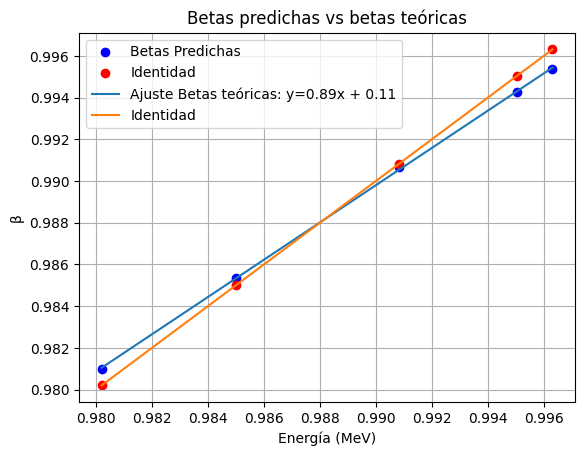



📊 ===== Iniciando Análisis Individual por Energía con Errores en Moda =====

--- Análisis para Energía = 3800 MeV ---
E = 3800 MeV: Beta Teórica = 0.98019801 | Moda = 0.97873855 ± 0.00000006 (SE Bootstrap)


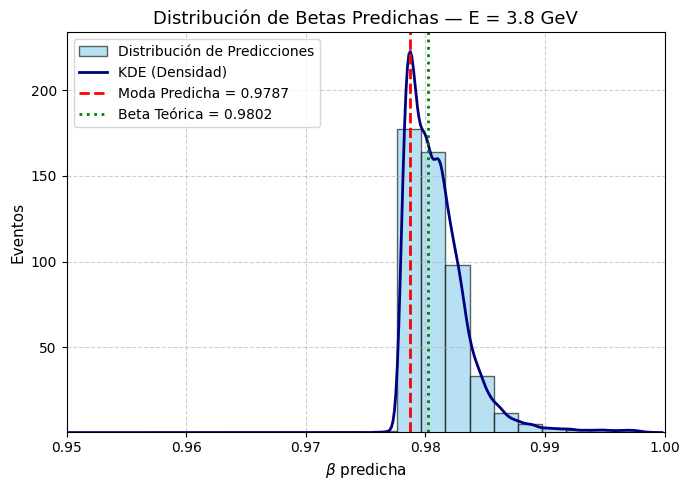


--- Análisis para Energía = 4500 MeV ---
E = 4500 MeV: Beta Teórica = 0.98500404 | Moda = 0.98467058 ± 0.00003261 (SE Bootstrap)


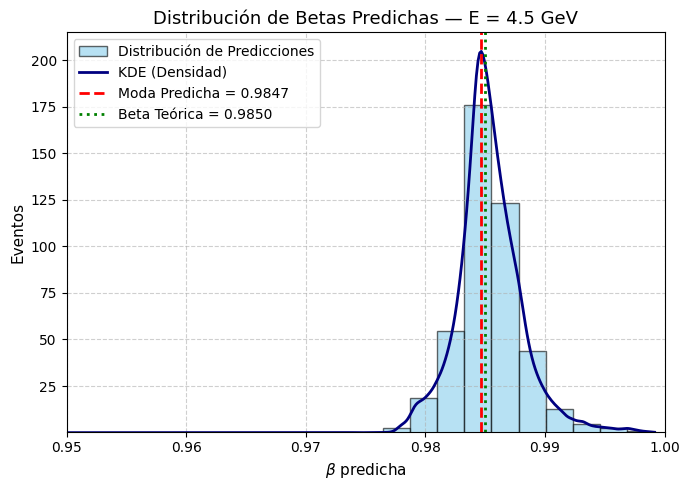


--- Análisis para Energía = 6000 MeV ---
E = 6000 MeV: Beta Teórica = 0.99081405 | Moda = 0.99101090 ± 0.00005313 (SE Bootstrap)


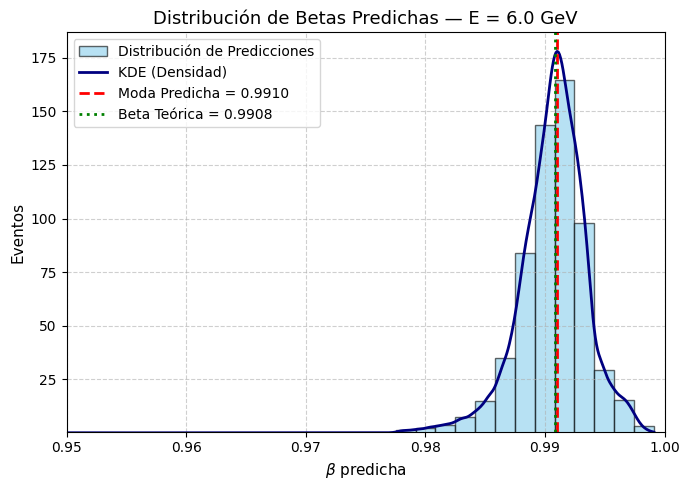


--- Análisis para Energía = 8500 MeV ---
E = 8500 MeV: Beta Teórica = 0.99504642 | Moda = 0.99371231 ± 0.00000006 (SE Bootstrap)


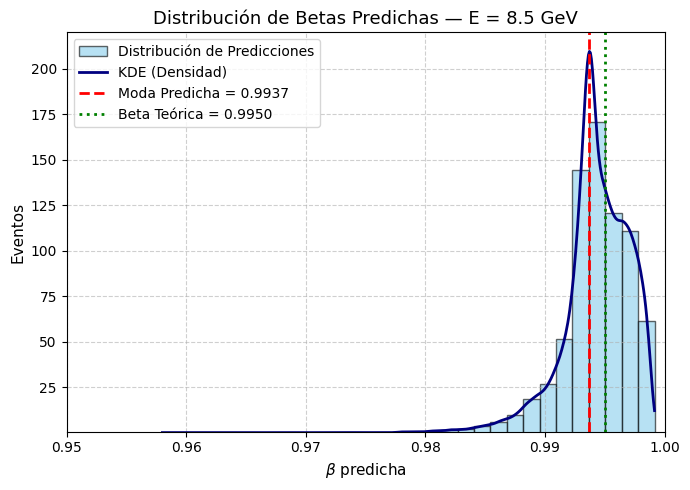


--- Análisis para Energía = 10000 MeV ---
E = 10000 MeV: Beta Teórica = 0.99631420 | Moda = 0.99727601 ± 0.00012093 (SE Bootstrap)


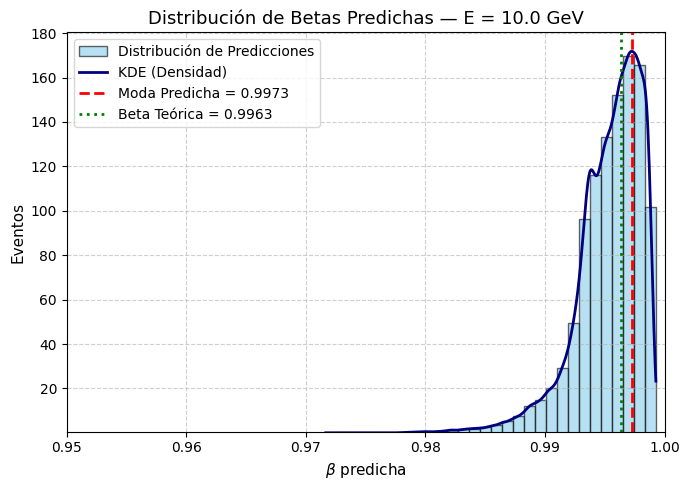

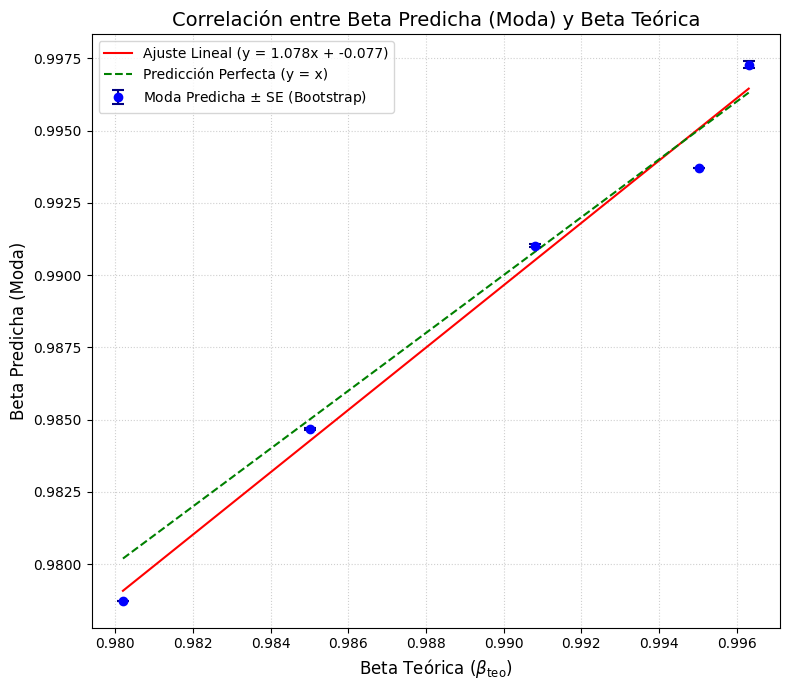

ValueError: 'yerr' must not contain negative values

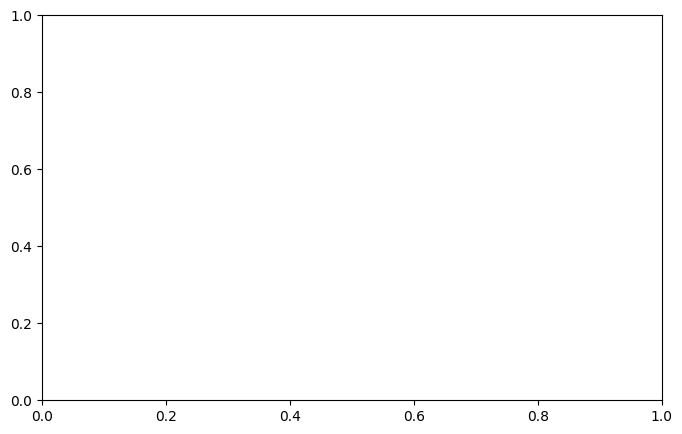

In [ ]:
print("Betas teoricas: ", betas_teo_list)
print("Betas predichas: ", mean_predicted_betas)
betas_teo = np.array(betas_teo_list, dtype=float)
beta_promedios = np.array(mean_predicted_betas, dtype=float)

m1, b1 = np.polyfit(betas_teo, beta_promedios, 1)
m2, b2 = np.polyfit(betas_teo, betas_teo, 1)
print(f"Pendiente de las betas predichas (m): {m1}")
print(f"Pendiente de las betas teóricas (m): {m2}")
print(f'Diferencia de pendientes: {np.abs(m1-m2)}')

plt.scatter(betas_teo, beta_promedios, marker='o', color='blue', label='Betas Predichas')
plt.scatter(betas_teo, betas_teo, marker='o', color='red', label='Identidad')
plt.plot(betas_teo, m1*betas_teo + b1, label=f'Ajuste Betas teóricas: y={m1:.2f}x + {b1:.2f}')
plt.plot(betas_teo, m2*betas_teo + b2, label='Identidad')
plt.title('Betas predichas vs betas teóricas')
plt.xlabel('Energía (MeV)')
plt.ylabel('β')
plt.legend()
plt.grid(True)
plt.show()

#MODAS
from scipy.stats import gaussian_kde

mode_predicted_betas = []  # Moda
mode_errors_boot = []      # Error estándar de la moda (Bootstrap)
iqr_lower_err = []         # Moda - P25
iqr_upper_err = []         # P75 - Moda
betas_teo_list = []
valid_E = []

print("\n\n📊 ===== Iniciando Análisis Individual por Energía con Errores en Moda =====")

for k, beta_preds in enumerate(all_predictions[:5]):
    if len(beta_preds) == 0:
        continue

    current_E = E[k]
    beta_teo = beta(current_E)
    print(f"\n--- Análisis para Energía = {current_E} MeV ---")

    # 1. Moda vía KDE
    kde = gaussian_kde(beta_preds)
    x_grid = np.linspace(beta_preds.min(), beta_preds.max(), 500)
    kde_values = kde(x_grid)
    beta_mode = x_grid[np.argmax(kde_values)]

    # 2. Error de dispersión: Rango Intercuartílico (Percentiles 25 y 75)
    p25 = np.percentile(beta_preds, 25)
    p75 = np.percentile(beta_preds, 75)
    iqr_lower_err.append(beta_mode - p25)
    iqr_upper_err.append(p75 - beta_mode)

    # 3. Incertidumbre de la Moda vía Bootstrap (100 réplicas)
    boot_modes = []
    n_samples = len(beta_preds)
    for _ in range(100):
        sample = np.random.choice(beta_preds, size=n_samples, replace=True)
        kde_b = gaussian_kde(sample)
        boot_modes.append(x_grid[np.argmax(kde_b(x_grid))])

    se_mode = np.std(boot_modes, ddof=1)
    mode_errors_boot.append(se_mode)

    mode_predicted_betas.append(beta_mode)
    betas_teo_list.append(beta_teo)
    valid_E.append(current_E)

    print(f"E = {current_E} MeV: Beta Teórica = {beta_teo:.8f} | Moda = {beta_mode:.8f} ± {se_mode:.8f} (SE Bootstrap)")

    # -------------------------------------------------------------
    # 📌 Histograma Independiente para la Energía Actual
    # -------------------------------------------------------------
    plt.figure(figsize=(7, 5))

    # 1. Histograma normalizado (densidad)
    count, bins, _ = plt.hist(
        beta_preds,
        bins=30,
        density=True,
        alpha=0.6,
        color='skyblue',
        edgecolor='black',
        label='Distribución de Predicciones'
    )

    # 2. Curva de densidad KDE
    plt.plot(x_grid, kde_values, color='navy', lw=2, label='KDE (Densidad)')

    # 3. Línea vertical para la Moda Predicha
    plt.axvline(
        beta_mode,
        color='red',
        linestyle='--',
        lw=2,
        label=f'Moda Predicha = {beta_mode:.4f}'
    )

    # 4. Línea vertical para el Valor Teórico
    plt.axvline(
        beta_teo,
        color='green',
        linestyle=':',
        lw=2,
        label=f'Beta Teórica = {beta_teo:.4f}'
    )

    plt.title(f'Distribución de Betas Predichas — E = {current_E/1000} GeV', fontsize=13)
    plt.xlabel(r'$\beta$ predicha', fontsize=11)
    plt.ylabel('Eventos', fontsize=11)
    #plt.yscale('log')
    plt.xlim(0.95, 1.0)
    plt.ylim(bottom=0.5)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()



# Conversión a arrays
betas_teo = np.array(betas_teo_list, dtype=float)
beta_modas = np.array(mode_predicted_betas, dtype=float)
valid_E = np.array(valid_E, dtype=float)
mode_errors_boot = np.array(mode_errors_boot, dtype=float)
iqr_errors = np.array([iqr_lower_err, iqr_upper_err]) # Forma (2, N) para barras asimétricas

# Ajuste Lineal
m, b = np.polyfit(betas_teo, beta_modas, 1)

plt.figure(figsize=(8, 7))

# Puntos con barras de error (Bootstrap SE)
plt.errorbar(
    betas_teo,
    beta_modas,
    yerr=abs(mode_errors_boot),  #Le puse abs() para que no tuviera valores negativos
    fmt='o',
    color='blue',
    ecolor='navy',
    elinewidth=1.5,
    capsize=4,
    capthick=1.5,
    label=r'Moda Predicha $\pm$ SE (Bootstrap)',
    zorder=5
)

plt.plot(betas_teo, m * betas_teo + b, color='red', linestyle='-', label=f'Ajuste Lineal (y = {m:.3f}x + {b:.3f})')
plt.plot(betas_teo, betas_teo, color='green', linestyle='--', label='Predicción Perfecta (y = x)')

plt.title(r'Correlación entre Beta Predicha (Moda) y Beta Teórica', fontsize=14)
plt.xlabel(r'Beta Teórica ($\beta_{\text{teo}}$)', fontsize=12)
plt.ylabel(r'Beta Predicha (Moda)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

# Graficar Moda con barras de error
plt.errorbar(
    valid_E,
    beta_modas,
    yerr=iqr_errors,  # O usa yerr=iqr_errors si prefieres ver la dispersión de datos
    fmt='-o',
    color='blue',
    ecolor='black',
    elinewidth=1.5,
    capsize=5,
    capthick=1.5,
    label=r'Betas Predichas (Moda $\pm$ SE)'
)

plt.plot(valid_E, betas_teo, marker='s', linestyle='--', color='red', label='Betas Teóricas')

plt.title('Betas Predichas (Moda) vs. Teóricas por Nivel de Energía', fontsize=14)
plt.xlabel('Energía (MeV)', fontsize=12)
plt.ylabel(r'$\beta$', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Esta celda profundiza en el análisis de correlación entre los valores teóricos y los predichos.

1.  **Preparación de Datos**: Convierte las listas de betas teóricas y medias de betas predichas en arrays de NumPy para facilitar los cálculos numéricos.
2.  **Ajuste Lineal**: Utiliza `np.polyfit` para realizar dos ajustes lineales:
    - **Ajuste 1 (`m1`, `b1`)**: Ajusta una línea a los puntos ($\beta_{teo}$, $\beta_{pred}$), para ver la tendencia real de las predicciones.
    - **Ajuste 2 (`m2`, `b2`)**: Ajusta una línea a los puntos ($\beta_{teo}$, $\beta_{teo}$). Esto simplemente da la línea de identidad (y=x), con una pendiente `m2` que debería ser 1.
3.  **Análisis de Pendientes**: Imprime las pendientes de ambos ajustes y su diferencia. Una diferencia cercana a cero indica que la tendencia de las predicciones es muy similar a la ideal.
4.  **Graficación de Correlación**: Crea un gráfico de dispersión (`scatter plot`) que visualiza:
    - **Puntos Azules**: Los datos reales ($\beta_{teo}$ vs $\beta_{pred}$).
    - **Puntos Rojos**: La línea de identidad, que representa una predicción perfecta.
    - **Línea Sólida**: El ajuste lineal a las predicciones.
    - **Línea Discontinua**: La línea de identidad.

Un buen modelo mostrará los puntos azules muy cerca de la línea roja/discontinua, y la línea de ajuste sólida casi superpuesta a la de identidad.